## Comparing Countries

#### Importing Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import f_oneway

### Loading the cleaned data

In [8]:
benin = pd.read_csv('../data/benin_clean.csv')
sierraleone = pd.read_csv('../data/sierraleone_clean.csv')
togo = pd.read_csv('../data/togo_clean.csv')

### General run through the dataset

In [9]:
print(benin.head())
print(sierraleone.head())
print(togo.head())
print(benin.shape)
print(sierraleone.shape)
print(togo.shape)

          Timestamp  GHI  DNI  DHI  ModA  ModB  Tamb    RH   WS  WSgust  \
0  2021-08-09 00:01 -1.2 -0.2 -1.1   0.0   0.0  26.2  93.4  0.0     0.4   
1  2021-08-09 00:02 -1.1 -0.2 -1.1   0.0   0.0  26.2  93.6  0.0     0.0   
2  2021-08-09 00:03 -1.1 -0.2 -1.1   0.0   0.0  26.2  93.7  0.3     1.1   
3  2021-08-09 00:04 -1.1 -0.1 -1.0   0.0   0.0  26.2  93.3  0.2     0.7   
4  2021-08-09 00:05 -1.0 -0.1 -1.0   0.0   0.0  26.2  93.3  0.1     0.7   

   WSstdev     WD  WDstdev   BP  Cleaning  Precipitation  TModA  TModB  
0      0.1  122.1      0.0  998         0            0.0   26.3   26.2  
1      0.0    0.0      0.0  998         0            0.0   26.3   26.2  
2      0.5  124.6      1.5  997         0            0.0   26.4   26.2  
3      0.4  120.3      1.3  997         0            0.0   26.4   26.3  
4      0.3  113.2      1.0  997         0            0.0   26.4   26.3  
          Timestamp  GHI  DNI  DHI  ModA  ModB  Tamb    RH   WS  WSgust  \
0  2021-10-30 00:01 -0.7 -0.1 -0.8  

### Add a 'Country' column to each dataset

In [10]:
benin['Country'] = 'Benin'
sierraleone['Country'] = 'Sierra Leone'
togo['Country'] = 'Togo'

### Combining the 3 datasets

In [11]:
data = pd.concat([benin, sierraleone, togo], ignore_index=True)


### Another run through the dataset

In [13]:
print(data.head())
print(data.describe(include='all'))
print(data.info())
print(data.shape)

          Timestamp  GHI  DNI  DHI  ModA  ModB  Tamb    RH   WS  WSgust  \
0  2021-08-09 00:01 -1.2 -0.2 -1.1   0.0   0.0  26.2  93.4  0.0     0.4   
1  2021-08-09 00:02 -1.1 -0.2 -1.1   0.0   0.0  26.2  93.6  0.0     0.0   
2  2021-08-09 00:03 -1.1 -0.2 -1.1   0.0   0.0  26.2  93.7  0.3     1.1   
3  2021-08-09 00:04 -1.1 -0.1 -1.0   0.0   0.0  26.2  93.3  0.2     0.7   
4  2021-08-09 00:05 -1.0 -0.1 -1.0   0.0   0.0  26.2  93.3  0.1     0.7   

   WSstdev     WD  WDstdev   BP  Cleaning  Precipitation  TModA  TModB Country  
0      0.1  122.1      0.0  998         0            0.0   26.3   26.2   Benin  
1      0.0    0.0      0.0  998         0            0.0   26.3   26.2   Benin  
2      0.5  124.6      1.5  997         0            0.0   26.4   26.2   Benin  
3      0.4  120.3      1.3  997         0            0.0   26.4   26.3   Benin  
4      0.3  113.2      1.0  997         0            0.0   26.4   26.3   Benin  
               Timestamp           GHI           DNI           

### Generate Boxplots for GHI, DNI, and DHI 

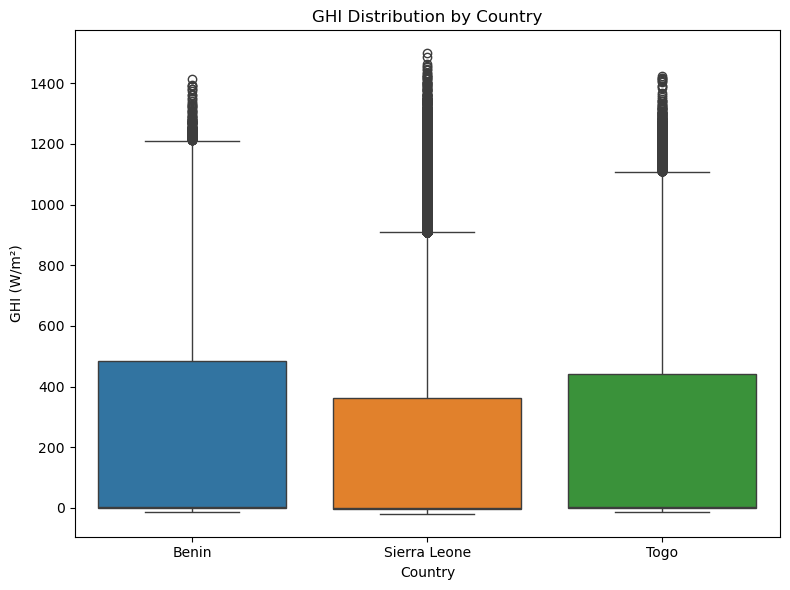

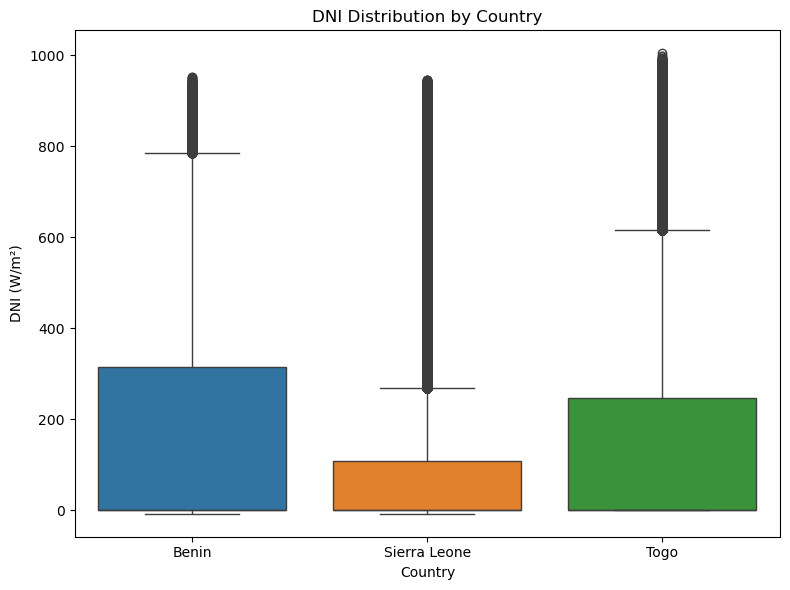

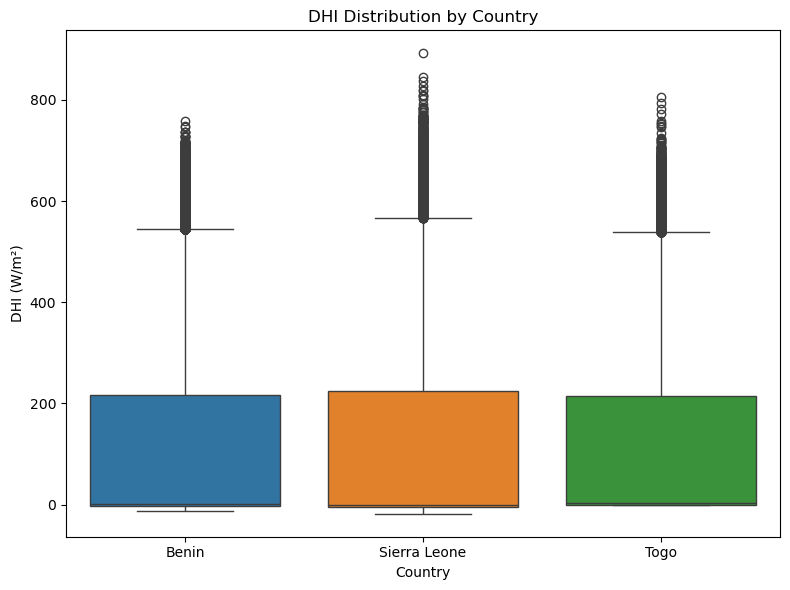

In [27]:
metrics = ['GHI', 'DNI', 'DHI']
for metric in metrics:
    plt.figure(figsize=(8, 6))
    sns.boxplot(x='Country', y=metric, data=data, hue = 'Country')
    plt.title(f'{metric} Distribution by Country')
    plt.ylabel(f'{metric} (W/m²)')
    plt.xlabel('Country')
    plt.tight_layout()
    plt.show()

### Summary Statistics Table

In [15]:
summary = data.groupby('Country')[metrics].agg(['mean', 'median', 'std']).round(2)
print(summary)


                 GHI                    DNI                    DHI         \
                mean median     std    mean median     std    mean median   
Country                                                                     
Benin         240.56    1.8  331.13  167.19   -0.1  261.71  115.36    1.6   
Sierra Leone  201.96    0.3  298.50  116.38   -0.1  218.65  113.72   -0.1   
Togo          230.56    2.1  322.53  151.26    0.0  250.96  116.44    2.5   

                      
                 std  
Country               
Benin         158.69  
Sierra Leone  158.95  
Togo          156.52  


### One-Way ANOVA

#### Extract GHI values for each country

In [16]:
ghi_benin = data[data['Country'] == 'Benin']['GHI']
ghi_sierraleone = data[data['Country'] == 'Sierra Leone']['GHI']
ghi_togo = data[data['Country'] == 'Togo']['GHI']

#### Checking extracted data

In [19]:
print(ghi_benin.head())
print(ghi_sierraleone.head())
print(ghi_togo.head())
print(ghi_benin.describe())
print(ghi_sierraleone.describe())
print(ghi_togo.describe())

0   -1.2
1   -1.1
2   -1.1
3   -1.1
4   -1.0
Name: GHI, dtype: float64
525600   -0.7
525601   -0.7
525602   -0.7
525603   -0.7
525604   -0.7
Name: GHI, dtype: float64
1051200   -1.3
1051201   -1.3
1051202   -1.3
1051203   -1.2
1051204   -1.2
Name: GHI, dtype: float64
count    525600.000000
mean        240.559452
std         331.131327
min         -12.900000
25%          -2.000000
50%           1.800000
75%         483.400000
max        1413.000000
Name: GHI, dtype: float64
count    525600.000000
mean        201.957515
std         298.495150
min         -19.500000
25%          -2.800000
50%           0.300000
75%         362.400000
max        1499.000000
Name: GHI, dtype: float64
count    525600.000000
mean        230.555040
std         322.532347
min         -12.700000
25%          -2.200000
50%           2.100000
75%         442.400000
max        1424.000000
Name: GHI, dtype: float64


#### Perform one-way ANOVA

In [32]:
f_stat, p_value = f_oneway(ghi_benin, ghi_sierraleone, ghi_togo)
print(f'F-statistic: {f_stat:.2f}')
print(f'P-value: {p_value:.10f}')

F-statistic: 2090.09
P-value: 0.0000000000


## SUMMARY
### Key Observations:
##### 1. Benin exhibits the highest mean, median and standard deviation GHI, suggesting strong solar potential.
##### 2. Sierra Leone shows the greatest variability in DNI, indicating fluctuating solar conditions.
##### 3. Togo has consistent DHI values, which may benefit diffuse solar applications.


### Visual Summary

In [ ]:
avg_ghi = data.groupby('Country')['GHI'].mean().sort_values(ascending=False)
plt.figure(figsize=(8, 6))
sns.barplot(x=avg_ghi.index, y=avg_ghi.values)
plt.title('Average GHI by Country')
plt.ylabel('Average GHI (W/m²)')
plt.xlabel('Country')
plt.tight_layout()
plt.show()

ValueError: Could not interpret value `Country` for `hue`. Value is a string, but `data` was not passed.

<Figure size 800x600 with 0 Axes>